# Descriptive Statistics

## Description and Summarization of data

Humans have been counting since the Paleolithic or the stone age, where our ancestors ([35,000 years ago](https://en.wikipedia.org/wiki/Tally_marks)) used some form of tally marks to count and keep track of quanties. The ancient civiliation such as the Babylonians conducted census to count people, livestocks and quantities. However, the idea became more popular and systematic duing Renaissance in the Italian city-states of Venice and Florence. 

The term statistics got its name from German statistik which came from Latin "statisticum" meaning state affairs. The idea spread through Europe and it became required to reigster birth, marriage and death. Reportings of mortality due to war, epidemic dieases, famines were popular in 1600s and later accounted for all causes of death. In this regard [John Graunt's Natural and Political Observations on the Bills of Mortality](https://doi.org/10.2307/2982578) is considered as a first attempt to draw scientific conclusion from statistical data, such as calculating the population of London using the average deaths by surveying household in certain London neighborhoods. 

It was useful during the plauge to track the mortality in form of tables and calculate mortality rate. The mortality tables were also used to compute the odds that a person of any age would live to any particular age, such data was useful for estimating insurance premium based on the age of the person.

Over the years, tables and graphs have been used for presenting data in many scenarios, often revealing useful insights about the data such as the range, the trend, the symmetry of data, clusters in the data, outliers and so on. 

Later it became popular as numerical science for other purposes as well but only in 1800s it started evolving as inferential tool with development of regression, correlation analysis and t-test.

In [153]:
import random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## Data Types and their level

TODO

- Discrete (Categorical/ numerical): Sample space contains a finite/countably infinite number of values (1,2,3,...).
- Continuous: if sample space contains an interval or continuous pan of real number. {h: h > 0}. Theoretically an infinite number of possible outcomes
- Categorical : if sample space contains objects that are grouped or categorized based on some qualitative traits.

- Qualitative
  - Categorical  (other types other than categorical in qualitative ?)
    - Nominal (?)
    - Ordinal (?)
- Quantitative
  - Integer ($\mathbb Z$)
  - Real ($\mathbb R$)
  - Complex ($\mathbb C$)



## Frequency Tables & Charts


### Data with small number of distinict values / categorical values

- Frequency tables & contingency tables (multiple dimension)
- line graph / bar graph

In [35]:
n = 1000
data = [random.choice([1.1, 0, 3.14, 0.4, 5.2, 16, 32]) for i in range(n)]

counts_dict = {}
for i in data:
  counts_dict[i] = counts_dict.get(i,0)+1
counts_dict

# Alternatively using pandas
series = pd.Series(data)
series.value_counts(sort=True)  # One-way frequency table

3.14     156
0.00     153
5.20     144
32.00    143
0.40     139
1.10     135
16.00    130
Name: count, dtype: int64

In [49]:
df = pd.DataFrame({'Grade': ['A+','A+','A-','B+','B+', 'B+', 'B1', 'C-', 'D+', 'D+'],
                   'Age': [16, 16, 16, 18, 18, 19, 19, 18, 17, 17],
                   'Gender': ['M','M', 'F', 'F', 'F', 'M', 'M', 'F', 'M', 'F']})

df.value_counts()  # counts unique combinations of all three variables

counts_df = pd.crosstab(index=df['Grade'], columns='counts')  # counts for 1 particular column (one-way frequency table)
counts_df

col_0,counts
Grade,
A+,2
A-,1
B+,3
B1,1
C-,1
D+,2


In [50]:
pd.crosstab(index=df['Age'], columns=df['Grade'])  
# counts for multiple variables, Two-Way Frequency Tables aka cross tabulation (contingency table)

Grade,A+,A-,B+,B1,C-,D+
Age,,,,,,
16,2,1,0,0,0,0
17,0,0,0,0,0,2
18,0,0,2,0,1,0
19,0,0,1,1,0,0


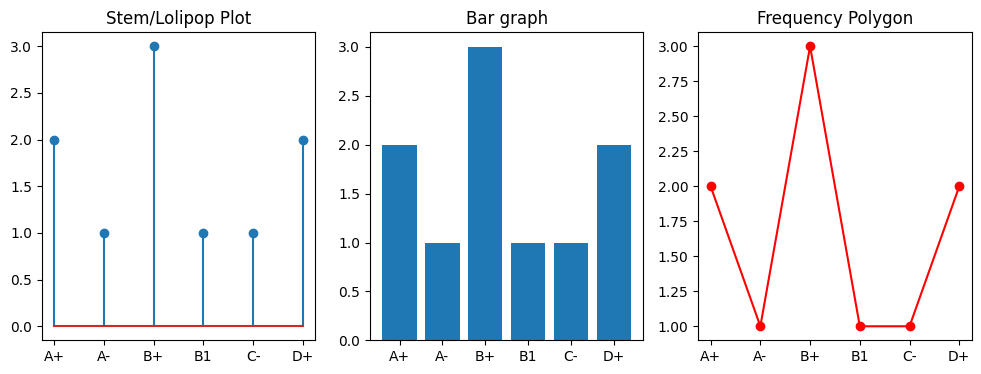

In [56]:
# L olipop / stem-line plots distinct data values on horizontal axis and frequencies on vertical

# bar graph: line in the graph are given added thickness
# frequency polygon: plot frequencies on vertical axis and then connects theplotted points with straight lines
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1); plt.stem(counts_df.index, counts_df); plt.title("Stem/Lolipop Plot")
plt.subplot(1, 3, 2); plt.bar(counts_df.index, counts_df.counts); plt.title("Bar graph")     
# counts_df.plot(kind="bar"), # plt.hist(data) -> hist directly from data
plt.subplot(1, 3, 3); plt.plot(counts_df.index, counts_df, 'ro-'); plt.title("Frequency Polygon");

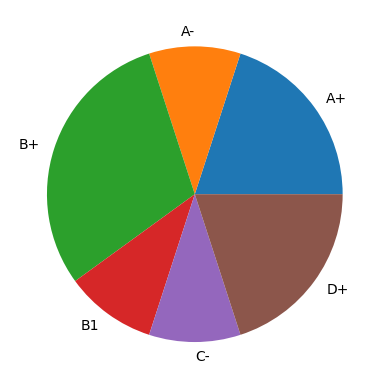

In [59]:
# Relative frequency is the ratio/fraction of frequency "f" of a particular value in a dataset of "n" value. i.e f/n
# Pie char is often used to indicate relative frequencies as areas of sector out of total circle when data are categorical
plt.pie(counts_df.counts, labels=counts_df.index);

### Data with large variations of data values

Grouped into (class) interval tables. The number of class intervals chosen is usally a trade-off between lossing too much information (too few classes) and difficulty in discerning patterns (too many classes, less frequencies). This can also be subjective choice. The endpoints (class boundaries) may overlap in the middle, hence left-end is usually included and right-end excluded, i.e 20-30 interval is [20,30) includes 20 but not 30.

In [136]:
# Class Frequency Table
l_limit, r_limit = 0,1800

data = np.random.randint(l_limit, r_limit, size=100); 
intervals = pd.IntervalIndex.from_tuples([(i,i+100) for i in range(l_limit,r_limit,200)])

class_freq_table = pd.cut(data, bins=intervals, right=False).value_counts().reset_index()  # bins also accept a scalar # bins
frequency, bins = np.histogram(data, bins=9, range=[l_limit, r_limit])

class_freq_table.columns = ['Class Interval', 'Frequency']
class_freq_table

,Class Interval,Frequency
0,"(0, 100]",4
1,"(200, 300]",4
2,"(400, 500]",7
3,"(600, 700]",7
4,"(800, 900]",5
5,"(1000, 1100]",3
6,"(1200, 1300]",2
7,"(1400, 1500]",5
8,"(1600, 1700]",8


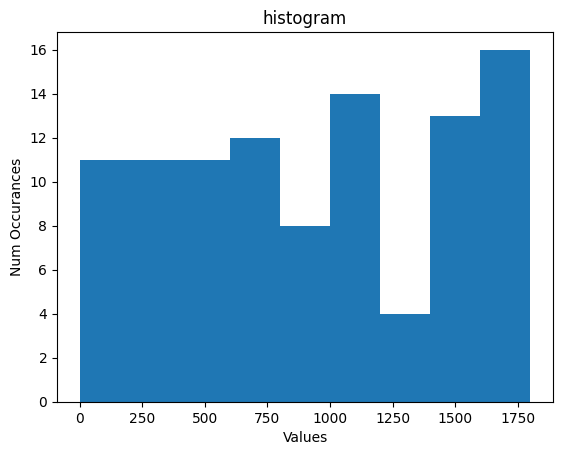

In [137]:
# Histogram: Graph plot of class data, with bars place adjacent to each other
plt.hist(data, bins=9, range=[l_limit, r_limit]); 
plt.title("histogram"); plt.ylabel("Num Occurances"); plt.xlabel("Values");

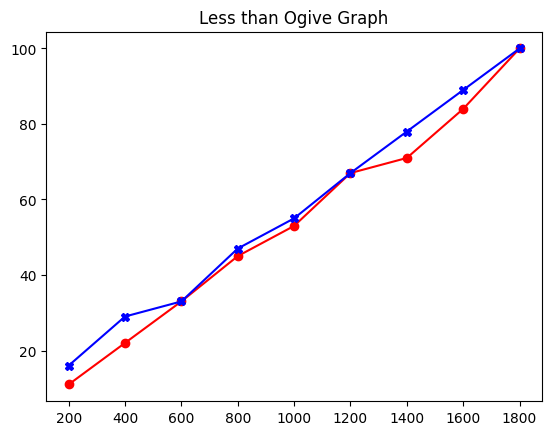

In [152]:
# Cumulative Frequency (ogive) Plot: gives the  number (or proportion) of data whose values are less/more than a point
cum_sum = np.cumsum(frequency)         # more than value of interval
cum_sum2 = np.cumsum(frequency[::-1])  # less than values of interval
plt.plot(bins[1:],cum_sum, 'ro-'); plt.title("More than Ogive Graph");
plt.plot(bins[1:],cum_sum2, 'bX-'); plt.title("Less than Ogive Graph");


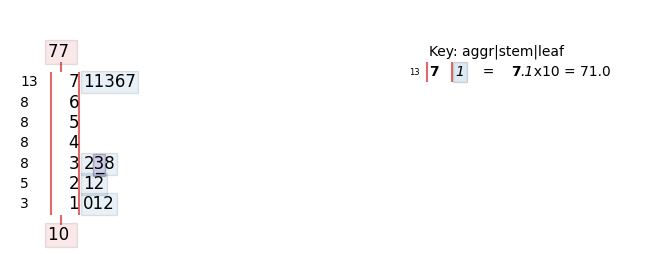

In [148]:
# Stem and leaf plot: divide data (eg: 62) into stem(6) and leaf(2)
# %pip install stemgraphic

import stemgraphic
stemgraphic.stem_graphic([10,11,12,21,22,32,33,38,71,73,77,76,71]);

## Central Tendency

"Center" of the data set is often used as a key statistics to get a feel for the data.

**Sample Mean** $$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$$
  - For data from frequency table we can use weighted mean $\bar{x} = \sum_{i=1}^k \frac{f_i*v_i}{n}$
  - Computation of mean for linear transformation in variable. $$y = ax +b \quad \rightarrow \quad \bar{y} =  \frac{1}{n} \sum_{i=1}^n (a * x_i + b) = a \bar{x} + b$$

**Sample Median**: Middle value ((n+1)/2 for odd n value, and average of n/2 and n/2 + 1 for even) when the data is arranged in ascending order.

**Sample Mode**: value(s) that occurs with highest frequency

In [179]:
## Mean

iris = load_iris(as_frame=True)
np.mean(iris.data[iris.target == 0]["sepal length (cm)"]),\
np.mean(iris.data[iris.target == 1]["sepal length (cm)"])

(5.006, 5.936)

## Spread (Variability) of Data

**Sample Variance** : Average square distance between the values. $$s^2 = = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2  \equiv  \frac{1}{n-1} \sum_{i=1}^n (x_i^2 - n \bar{x}^2)$$
  - Computation of mean for linear transformation in variable. $$ y = ax +b \rightarrow \bar{y} = a \bar{x} +b \rightarrow s_y^2 = = \frac{1}{n-1} \sum_{i=1}^n (y_i - \bar{y})^2 = a^2 s_x^2$$
  - Sample mean tend to be closer to the data than the actual population mean, if we divide by $n$ instead of $n-1$ which results in smaller sample variance than the true population variance. This is more siginficant for small sample size $n$. Bessel's Correction applies $n-1$ instead of $n$ in the formula for sample variance to correct this bias in under-estimation of population variance.

**Sample Standard Deviation** : Positive square root of sample variance converts variance to the same units as the data values. $$s^2 = = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2} $$



In [180]:
np.var(iris.data[iris.target == 0]["sepal length (cm)"]),\
np.var(iris.data[iris.target == 1]["sepal length (cm)"])

(0.12176400000000002, 0.261104)

## Percentiles

- Sample percentiles (eg: tells which value is greater than 95% of all the data)

The sample 100p percentile is that data value such that at least 100p percent of the data are less than or equal to it and at least 100(1 − p) percent are greater than or equal to it.

- Sample quartiles

- Sample quantiles


- Range
- Interquartile range

In [ ]:
## Box-Whisker Plots



Chebyshev's inquality for sample data gives upper bound to the proportion of the data that can differ from the sample mean by more than k times the sample standard deviation. 

We can obtain more precise estimates of the proportion of the data that is within k sample standard deviations of the sample mean.

## The bell-shaped data-set

estimates given by "empirical rule"

Scattered diagram for Paired value data to study correlations